In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.neighbors import BallTree

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/processed/clean_house_data.csv")

print("Dataset Loaded Successfully")

print()

print("Dataset Shape :", df.shape)

df.head()

Dataset Loaded Successfully

Dataset Shape : (21613, 24)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,Sale Year,House Age,geometry
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,59,POINT (-122.257 47.5112)
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,63,POINT (-122.319 47.721)
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,82,POINT (-122.233 47.7379)
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,49,POINT (-122.393 47.5208)
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,28,POINT (-122.045 47.6168)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [4]:
print("Latitude Range")

print(df["lat"].describe())

print()

print("Longitude Range")

print(df["long"].describe())

Latitude Range
count    21613.000000
mean        47.560053
std          0.138564
min         47.155900
25%         47.471000
50%         47.571800
75%         47.678000
max         47.777600
Name: lat, dtype: float64

Longitude Range
count    21613.000000
mean      -122.213896
std          0.140828
min       -122.519000
25%       -122.328000
50%       -122.230000
75%       -122.125000
max       -121.315000
Name: long, dtype: float64


In [5]:
coordinates = np.radians(df[["lat", "long"]])

coordinates[:5]

,lat,long
0,0.829227,-2.133787
1,0.832889,-2.134869
2,0.833184,-2.133368
3,0.829394,-2.136161
4,0.831070,-2.130087


In [6]:
tree = BallTree(coordinates,metric="haversine")

print("BallTree Created Successfully")

BallTree Created Successfully


In [7]:
k = 6

distances, indices = tree.query(coordinates,k=k)

print("Neighbour Search Completed")

Neighbour Search Completed


In [8]:
EARTH_RADIUS = 6371

distances_km = distances * EARTH_RADIUS

distances_km[:5]

array([[0.        , 0.04447797, 0.05559746, 0.07592491, 0.08218086,
        0.16436133],
       [0.        , 0.07562742, 0.08190649, 0.13401594, 0.13401594,
        0.15297167],
       [0.        , 0.14336372, 0.1445534 , 0.14997495, 0.16860338,
        0.19321019],
       [0.        , 0.05559746, 0.06671696, 0.20845081, 0.26182688,
        0.26654517],
       [0.        , 0.01111949, 0.08204265, 0.08895594, 0.11632418,
        0.21611945]])

In [9]:
example = pd.DataFrame({
    "Neighbour": range(6),
    "Distance (km)": distances_km[0]
})

example

,Neighbour,Distance (km)
0,0,0.000000
1,1,0.044478
2,2,0.055597
3,3,0.075925
4,4,0.082181
5,5,0.164361


In [10]:
df["Nearest Neighbor Distance (km)"] = distances_km[:, 1]

df[["lat","long","Nearest Neighbor Distance (km)"]].head()

,lat,long,Nearest Neighbor Distance (km)
0,47.5112,-122.257,0.044478
1,47.7210,-122.319,0.075627
2,47.7379,-122.233,0.143364
3,47.5208,-122.393,0.055597
4,47.6168,-122.045,0.011119


In [11]:
df["Average Neighbor Distance (km)"] = distances_km[:, 1:].mean(axis=1)

df[["Average Neighbor Distance (km)"]].head()

,Average Neighbor Distance (km)
0,0.084509
1,0.115707
2,0.159941
3,0.171827
4,0.102912


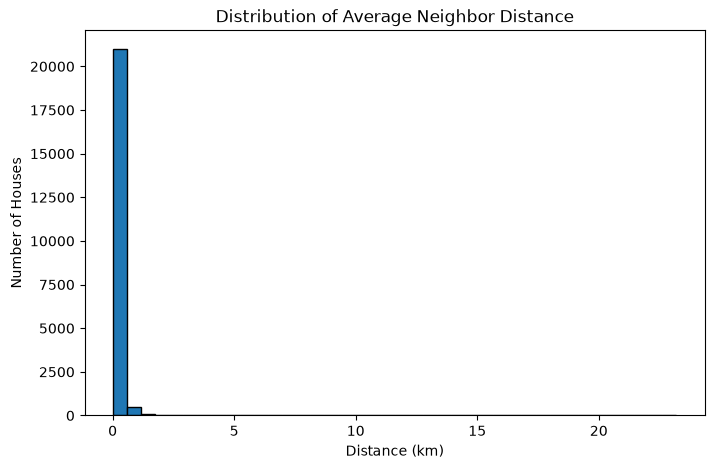

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["Average Neighbor Distance (km)"],bins=40,edgecolor="black")

plt.title("Distribution of Average Neighbor Distance")

plt.xlabel("Distance (km)")

plt.ylabel("Number of Houses")

plt.show()

In [13]:
neighbor_avg_price = []

for neighbor in indices:
    avg_price = df.iloc[neighbor[1:]]["price"].mean()
    neighbor_avg_price.append(avg_price)

df["Neighborhood Average Price"] = neighbor_avg_price

df[["price","Neighborhood Average Price"]].head()

,price,Neighborhood Average Price
0,221900.0,285200.0
1,538000.0,394400.0
2,180000.0,527640.0
3,604000.0,633300.0
4,510000.0,517400.0


In [14]:
df["Neighborhood Price Difference"] = (df["price"] - df["Neighborhood Average Price"])

df[["Neighborhood Price Difference"]].head()

,Neighborhood Price Difference
0,-63300.0
1,143600.0
2,-347640.0
3,-29300.0
4,-7400.0


In [15]:
density = []

for row in distances_km:
    nearby = np.sum(row[1:] <= 2)
    density.append(nearby)

df["Nearby Houses (2 km)"] = density

df[["Nearby Houses (2 km)"]].head()

,Nearby Houses (2 km)
0,5
1,5
2,5
3,5
4,5


In [16]:
df["Price Density"] = (df["Neighborhood Average Price"] / (df["Average Neighbor Distance (km)"] + 0.001))

df[["Price Density"]].head()

,Price Density
0,3.335341e+06
1,3.379389e+06
2,3.278466e+06
3,3.664348e+06
4,4.979197e+06


In [17]:
spatial_features = [
    "price",
    "Nearest Neighbor Distance (km)",
    "Average Neighbor Distance (km)",
    "Neighborhood Average Price",
    "Neighborhood Price Difference",
    "Nearby Houses (2 km)",
    "Price Density"
]

df[spatial_features].corr().round(3)

,price,Nearest Neighbor Distance (km),Average Neighbor Distance (km),Neighborhood Average Price,Neighborhood Price Difference,Nearby Houses (2 km),Price Density
price,1.000,0.013,0.010,0.837,0.489,0.012,0.368
Nearest Neighbor Distance (km),0.013,1.000,0.915,0.002,0.021,-0.464,-0.179
Average Neighbor Distance (km),0.010,0.915,1.000,-0.001,0.019,-0.600,-0.262
Neighborhood Average Price,0.837,0.002,-0.001,1.000,-0.068,0.020,0.456
Neighborhood Price Difference,0.489,0.021,0.019,-0.068,1.000,-0.009,-0.057
Nearby Houses (2 km),0.012,-0.464,-0.600,0.020,-0.009,1.000,0.057
Price Density,0.368,-0.179,-0.262,0.456,-0.057,0.057,1.000


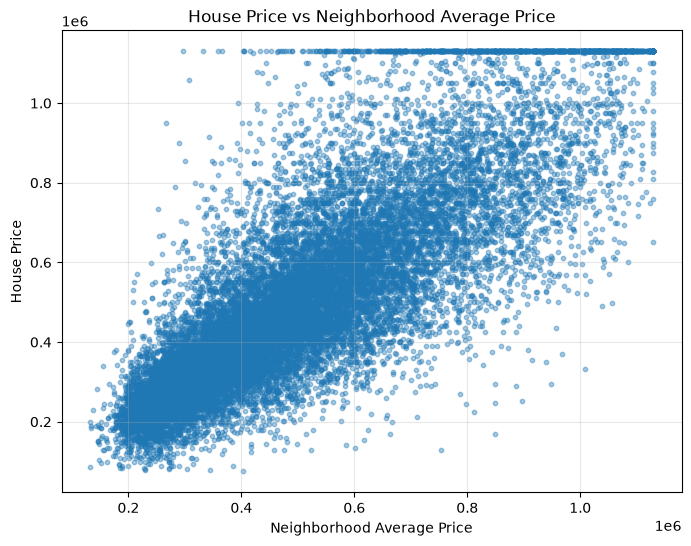

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df["Neighborhood Average Price"],df["price"],alpha=0.4,s=10)

plt.xlabel("Neighborhood Average Price")

plt.ylabel("House Price")

plt.title("House Price vs Neighborhood Average Price")

plt.grid(alpha=0.3)

plt.show()

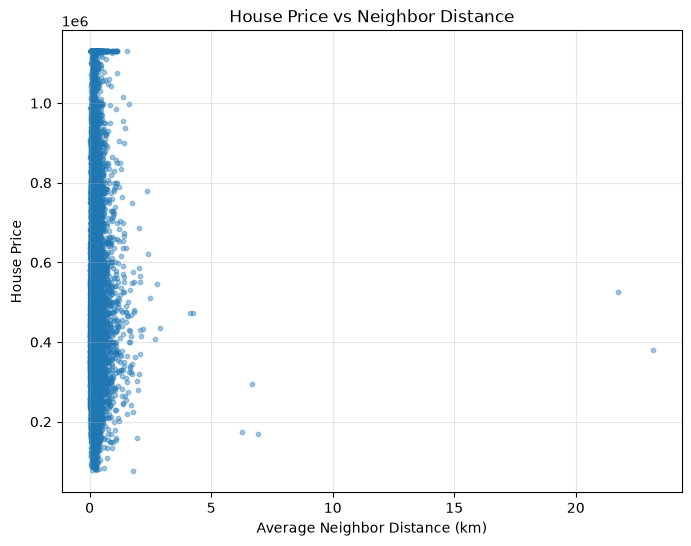

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(df["Average Neighbor Distance (km)"],df["price"],alpha=0.4,s=10)

plt.xlabel("Average Neighbor Distance (km)")

plt.ylabel("House Price")

plt.title("House Price vs Neighbor Distance")

plt.grid(alpha=0.3)

plt.show()

In [20]:
top10 = df.sort_values(by="Neighborhood Average Price",ascending=False)[[
    "price",
    "Neighborhood Average Price",
    "Nearest Neighbor Distance (km)",
    "Nearby Houses (2 km)"
]].head(10)

top10

,price,Neighborhood Average Price,Nearest Neighbor Distance (km),Nearby Houses (2 km)
11975,1129575.0,1129575.0,0.100075,5
7911,1129575.0,1129575.0,0.159827,5
21540,1129575.0,1129575.0,0.225203,5
8910,1129575.0,1129575.0,0.078161,5
16580,1129575.0,1129575.0,0.074925,5
2181,1129575.0,1129575.0,0.143446,5
6823,1129575.0,1129575.0,0.078180,5
10468,1129575.0,1129575.0,0.100075,5
21530,1129575.0,1129575.0,0.100343,5
3281,1129575.0,1129575.0,0.044478,5


In [21]:
summary = df[[
    "Nearest Neighbor Distance (km)",
    "Average Neighbor Distance (km)",
    "Neighborhood Average Price",
    "Neighborhood Price Difference",
    "Nearby Houses (2 km)",
    "Price Density"
]].describe().round(2)

summary

,Nearest Neighbor Distance (km),Average Neighbor Distance (km),Neighborhood Average Price,Neighborhood Price Difference,Nearby Houses (2 km),Price Density
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,0.10,0.20,506909.90,4677.38,4.99,3677737.87
std,0.24,0.28,218642.55,137103.66,0.15,2940840.77
min,0.00,0.01,131600.00,-679598.00,0.00,16356.94
25%,0.04,0.11,334290.00,-66790.00,5.00,1807692.78
50%,0.08,0.15,464900.00,-1600.00,5.00,2997552.05
75%,0.12,0.22,631260.00,61184.60,5.00,4796568.19
max,22.66,23.19,1129575.00,832675.00,5.00,73803762.51


In [22]:
print("Final Dataset Shape")

print(df.shape)

print()

print("New Spatial Features Added")

new_features = [
    "Nearest Neighbor Distance (km)",
    "Average Neighbor Distance (km)",
    "Neighborhood Average Price",
    "Neighborhood Price Difference",
    "Nearby Houses (2 km)",
    "Price Density"
]

print(new_features)

Final Dataset Shape
(21613, 30)

New Spatial Features Added
['Nearest Neighbor Distance (km)', 'Average Neighbor Distance (km)', 'Neighborhood Average Price', 'Neighborhood Price Difference', 'Nearby Houses (2 km)', 'Price Density']


In [23]:
df.to_csv("../data/processed/spatial_features.csv",index=False)

print("Spatial Feature Dataset Saved Successfully.")

Spatial Feature Dataset Saved Successfully.
